<a href="https://colab.research.google.com/github/ancestor9/mathematics-for-machine-learning/blob/main/pytorch_recap/02_pytorch_autograd_sgd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

# x 텐서의 미분값을 계산할 수 있도록 설정
x = torch.tensor(2.0, requires_grad=True)

# y는 x를 이용한 연산이므로 자동으로 미분 가능해짐
y = x**2
z = y * 3

print(z)
print(z.requires_grad) # True


tensor(12., grad_fn=<MulBackward0>)
True


In [ ]:
import torch

# x 텐서 정의 (미분 계산을 위해 requires_grad=True)
x = torch.tensor(2.0, requires_grad=True)

# 계산 그래프를 생성하는 연산
y = x**2
z = 3 * y

# z를 x에 대해 미분
# dz/dx = 3 * (2x) = 6x
# x=2 이므로, dz/dx = 12
z.backward()

# x의 미분값(기울기) 확인
# z에 대한 x의 기울기(gradient)
print(f"x의 미분값(dz/dx): {x.grad}") # 출력: 12.0


x의 미분값(dz/dx): 12.0


In [ ]:
import sympy

x = sympy.Symbol('x')
y = x**2
z = 3 * y

# z를 x에 대해 미분
dz_dx = sympy.diff(z, x)

print(f"Original function z: {z}")
print(f"Symbolic derivative dz/dx: {dz_dx}")

Original function z: 3*x**2
Symbolic derivative dz/dx: 6*x


## **Perceptron**

In [ ]:
# 학습할 가중치(w)와 편향(b) 정의
# 이 두 텐서의 미분값을 계산해야 하므로 requires_grad=True 설정
w = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)

# 입력 데이터와 정답 데이터
x = torch.tensor(2.0)
y_true = torch.tensor(5.0) # 실제 정답

# 순전파(Forward Propagation)
# 모델의 예측값 계산
y_pred = w * x + b

# 손실(Loss) 계산 (예측값과 정답의 차이)
loss = (y_pred - y_true)**2

print(f"예측값: {y_pred.item()}")
print(f"손실: {loss.item()}")

# 역전파(Backpropagation)
# 손실에 대해 w와 b의 미분값 계산
loss.backward()

# w와 b의 미분값(기울기) 확인
# 이 기울기를 이용해 w와 b를 업데이트하여 손실을 줄일 수 있음
print(f"w의 미분값: {w.grad}")
print(f"b의 미분값: {b.grad}")


예측값: 3.0
손실: 4.0
w의 미분값: -8.0
b의 미분값: -4.0


In [ ]:
learning_rate = 0.01

# w와 b 업데이트 (경사 하강법)
# w.grad와 b.grad는 이전 역전파에서 계산된 미분값
with torch.no_grad(): # 기울기 계산을 추적하지 않도록 설정
    w -= learning_rate * w.grad
    b -= learning_rate * b.grad

    # 다음 역전파를 위해 기울기를 0으로 초기화
    w.grad.zero_()
    b.grad.zero_()

print(f"업데이트된 w: {w.item()}")
print(f"업데이트된 b: {b.item()}")


업데이트된 w: 1.0800000429153442
업데이트된 b: 1.0399999618530273


### 학습 과정 반복 (경사 하강법)

In [ ]:
import torch

# 학습할 가중치(w)와 편향(b) 정의
# 이 두 텐서의 미분값을 계산해야 하므로 requires_grad=True 설정
w = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)

# 입력 데이터와 정답 데이터
x = torch.tensor(2.0)
y_true = torch.tensor(5.0) # 실제 정답

# 학습률(Learning Rate) 및 에포크(Epochs) 설정
learning_rate = 0.01
epochs = 200

print(f"초기 w: {w.item()}, 초기 b: {b.item()}\n")

for epoch in range(epochs):
    # 순전파(Forward Propagation)
    # 모델의 예측값 계산
    y_pred = w * x + b

    # 손실(Loss) 계산 (예측값과 정답의 차이)
    loss = (y_pred - y_true)**2

    # 역전파(Backpropagation)
    # 손실에 대해 w와 b의 미분값 계산
    loss.backward()

    # w와 b 업데이트 (경사 하강법)
    with torch.no_grad(): # 기울기 계산을 추적하지 않도록 설정
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad

        # 다음 역전파를 위해 기울기를 0으로 초기화
        # 이전에 계산된 기울기는 현재 스텝에서만 유효하므로 반드시 0으로 초기화해야 함
        w.grad.zero_()
        b.grad.zero_()

    # 학습 과정 출력 (20 에포크마다)
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch + 1}/{epochs}: Loss = {loss.item():.4f}, Predicted y = {y_pred.item():.4f}, w = {w.item():.4f}, b = {b.item():.4f}")

print(f"\n최종 w: {w.item():.4f}, 최종 b: {b.item():.4f}")
print(f"예측값: {y_pred.item()}")
print(f"정답: {y_true.item()}")
print(f"손실: {loss.item()}")


초기 w: 1.0, 초기 b: 1.0

Epoch 20/200: Loss = 0.0730, Predicted y = 4.7298, w = 1.7027, b = 1.3514
Epoch 40/200: Loss = 0.0011, Predicted y = 4.9672, w = 1.7882, b = 1.3941
Epoch 60/200: Loss = 0.0000, Predicted y = 4.9960, w = 1.7986, b = 1.3993
Epoch 80/200: Loss = 0.0000, Predicted y = 4.9995, w = 1.7998, b = 1.3999
Epoch 100/200: Loss = 0.0000, Predicted y = 4.9999, w = 1.8000, b = 1.4000
Epoch 120/200: Loss = 0.0000, Predicted y = 5.0000, w = 1.8000, b = 1.4000
Epoch 140/200: Loss = 0.0000, Predicted y = 5.0000, w = 1.8000, b = 1.4000
Epoch 160/200: Loss = 0.0000, Predicted y = 5.0000, w = 1.8000, b = 1.4000
Epoch 180/200: Loss = 0.0000, Predicted y = 5.0000, w = 1.8000, b = 1.4000
Epoch 200/200: Loss = 0.0000, Predicted y = 5.0000, w = 1.8000, b = 1.4000

최종 w: 1.8000, 최종 b: 1.4000
예측값: 4.999998569488525
정답: 5.0
손실: 2.0463630789890885e-12


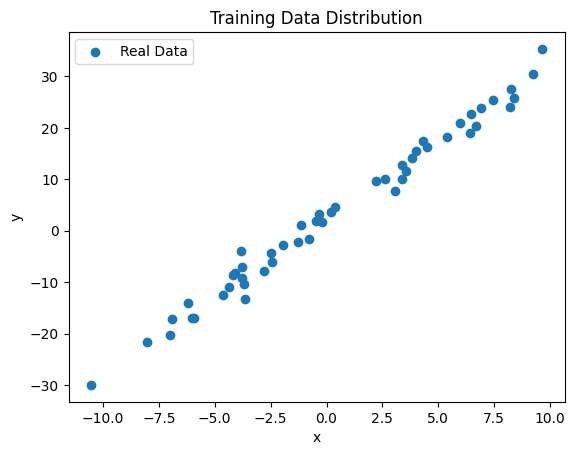

In [ ]:
import matplotlib.pyplot as plt

# 데이터 생성: y = 3x + 2
torch.manual_seed(42)
x_train = torch.randn(50, 1) * 5
y_label = 3 * x_train + 2 + torch.randn(50, 1) * 2 # Changed 10 to 50 here to match x_train size

# 시각화
plt.scatter(x_train, y_label, label='Real Data')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Training Data Distribution')
plt.legend()
plt.show()

## **backward()** : 손실을 줄이기 위해 어느 방향으로 움직여야 할지(기울기)를 계산
## **optimizer.step()** : 그 방향으로 실제로 한 발자국(학습률 만큼) 내딛는 동작

In [ ]:
import torch.optim as optim

# 가중치 초기화
w = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)

# SGD 옵티마이저 설정 (학습률 0.01)
optimizer = optim.SGD([w, b], lr=0.01)

# 학습 데이터
x = torch.tensor(2.0)
y_true = torch.tensor(5.0)

# 1. 미분값 초기화
optimizer.zero_grad()

# 2. 순전파 및 손실 계산
y_pred = w * x + b
loss = (y_pred - y_true)**2

# 3. 역전파 (기울기 계산)
loss.backward()

# 4. 가중치 업데이트 (위의 수식 과정 수행)
optimizer.step()

print(f"업데이트 후 w: {w.item():.2f}") # 1.08
print(f"업데이트 후 b: {b.item():.2f}") # 1.04

업데이트 후 w: 1.08
업데이트 후 b: 1.04


## **epoch을 여러번 수행**
- 위의 과정을 수천 번 반복하면 모델의 선이 실제 데이터 포인트들을 가장 잘 관통하는 위치($w=3, b=2$ 근처)를 찾아감

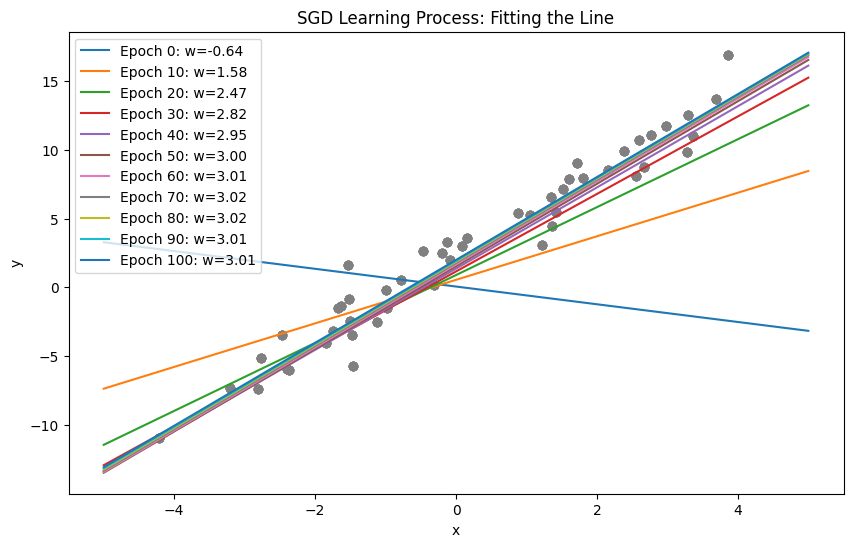

최종 결과 - w: 3.0111, b: 1.9915


In [ ]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. 데이터 생성 (y = 3x + 2)
torch.manual_seed(42)
x_train = torch.randn(50, 1) * 2
y_label = 3 * x_train + 2 + torch.randn(50, 1) * 1.5 # 노이즈 추가

# 2. 모델 파라미터 초기화 (임의의 값)
w = torch.tensor([-1.0], requires_grad=True)
b = torch.tensor([0.0], requires_grad=True)

# 3. 옵티마이저 설정
optimizer = optim.SGD([w, b], lr=0.01)

# 시각화 준비
plt.figure(figsize=(10, 6))

# 4. 학습 시작 (30번 반복)
for epoch in range(101):
    # 순전파
    y_pred = w * x_train + b
    loss = torch.mean((y_pred - y_label)**2) # MSE 손실

    # 역전파 및 업데이트
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # 시각화: 10회 학습마다 직선을 그림
    if epoch % 10 == 0:
        plt.scatter(x_train.numpy(), y_label.numpy(), color='gray', alpha=0.5)
        line_x = torch.linspace(-5, 5, 10)
        line_y = w.item() * line_x + b.item()
        plt.plot(line_x.numpy(), line_y.numpy(), label=f'Epoch {epoch}: w={w.item():.2f}')

plt.title("SGD Learning Process: Fitting the Line")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

print(f"최종 결과 - w: {w.item():.4f}, b: {b.item():.4f}")

## 실습문제

z = 2 * (x**3) 이라는 수식이 있습니다. x가 4일 때, z.backward()를 호출하면 x.grad의 값은 얼마가 될까요? 직접 손으로 계산해보고, PyTorch 코드로 확인해 보세요.

In [ ]:
# 1. x 정의 및 미분 추적 설정 (x = 3)
x = torch.tensor(4.0, requires_grad=True)

# 2. 수식 z = 2 * x^3 정의
z = 2 * (x**3)

# 3. 역전파(Backpropagation) 수행
z.backward()

# 4. 결과 출력
print(f"x의 값: {x.item()}")
print(f"z의 값: {z.item()}")
print(f"x.grad (미분값): {x.grad.item()}")

x의 값: 4.0
z의 값: 128.0
x.grad (미분값): 96.0



y = x**2 이라는 수식이 있습니다. x축과 y축으로 원래 그래프와 x가 변할 때 z.backward()를 호출하면 x.grad의 값은 얼마가 될까요? 시각화 코드를 주라

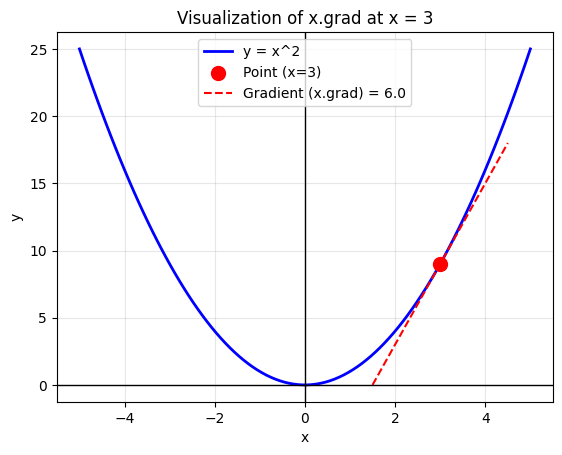

x가 3일 때, y의 값은 9이고 x.grad(기울기)는 6.0입니다.


In [ ]:
def visualize_gradient(x_value):
    # 1. PyTorch를 이용한 미분 계산
    x = torch.tensor(float(x_value), requires_grad=True)
    y = x**2
    y.backward()
    grad = x.grad.item() # 이것이 바로 우리가 원하는 x.grad

    # 2. 그래프 데이터 준비
    x_np = np.linspace(-5, 5, 100)
    y_np = x_np**2

    # 3. 시각화
    plt.figure()
    plt.plot(x_np, y_np, label='y = x^2', color='blue', lw=2) # 원래 함수

    # 선택한 점 표시
    plt.scatter([x_value], [x_value**2], color='red', s=100, zorder=5, label=f'Point (x={x_value})')

    # 접선 그리기: y - y1 = m(x - x1) => y = m(x - x1) + y1
    tangent_x = np.linspace(x_value - 1.5, x_value + 1.5, 10)
    tangent_y = grad * (tangent_x - x_value) + (x_value**2)
    plt.plot(tangent_x, tangent_y, color='red', linestyle='--', label=f'Gradient (x.grad) = {grad}')

    plt.axhline(0, color='black', lw=1)
    plt.axvline(0, color='black', lw=1)
    plt.title(f'Visualization of x.grad at x = {x_value}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"x가 {x_value}일 때, y의 값은 {x_value**2}이고 x.grad(기울기)는 {grad}입니다.")

# x가 3일 때의 결과 확인
visualize_gradient(3)

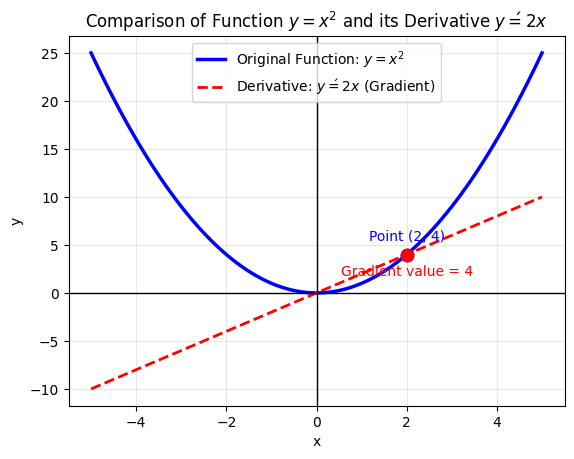

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 데이터 준비
# x축 데이터: -5부터 5까지 100개의 점
x = np.linspace(-5, 5, 100)

# 원래 함수: y = x^2
y = x**2

# 미분 함수: y' = 2x
dy_dx = 2 * x

# 2. 시각화
plt.figure()

# 원래 함수 y = x^2 그래프 (파란색 실선)
plt.plot(x, y, label=r'Original Function: $y = x^2$', color='blue', lw=2.5)

# 미분 함수 y' = 2x 그래프 (빨간색 점선)
plt.plot(x, dy_dx, label=r'Derivative: $y\' = 2x$ (Gradient)', color='red', linestyle='--', lw=2)

# 참고용 점들 표시 (예: x = 2일 때)
point_x = 2
point_y = point_x**2 # 4
point_grad = 2 * point_x # 4

# 원래 함수 위의 점
plt.scatter([point_x], [point_y], color='blue', s=80, zorder=5)
plt.annotate(f'Point (2, 4)', (point_x, point_y), textcoords="offset points", xytext=(0,10), ha='center', color='blue')

# 미분 함수 위의 점 (이 점의 y값이 위 점의 기울기)
plt.scatter([point_x], [point_grad], color='red', s=80, zorder=5)
plt.annotate(f'Gradient value = {point_grad}', (point_x, point_grad), textcoords="offset points", xytext=(0,-15), ha='center', color='red')

# 그래프 설정
plt.axhline(0, color='black', lw=1) # x축
plt.axvline(0, color='black', lw=1) # y축
plt.title(r'Comparison of Function $y=x^2$ and its Derivative $y\'=2x$')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper center')

plt.show()